In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

## Классная работа

In [ ]:
import torch

H, W = 16, 16           # размеры изображения: H - число строк; W - число столбцов
kernel_size = (3, 3)    # размер ядра по осям (H, W)
stride = (1, 1)         # шаг смещения ядра по осям (H, W)
padding = 0             # размер нулевой области вокруг изображения (число строк и столбцов с каждой стороны)

H_out = int((H + 2 * padding - kernel_size[0]) / stride[0] + 1)
W_out = int((W + 2 * padding - kernel_size[1]) / stride[1] + 1)

x = torch.randint(0, 255, (H, W), dtype=torch.float32) # входное изображение
kernel = torch.rand(kernel_size) # ядро

predict = torch.empty(H_out, W_out, dtype=torch.float32)
for i in range(0, H_out):
    for j in range(0, W_out):
        predict[i, j] = torch.sum(x[i*stride[0]:kernel_size[0]+i*stride[0],
                                  j*stride[1]:kernel_size[1]+j*stride[1]] * kernel)

## Домашняя работа

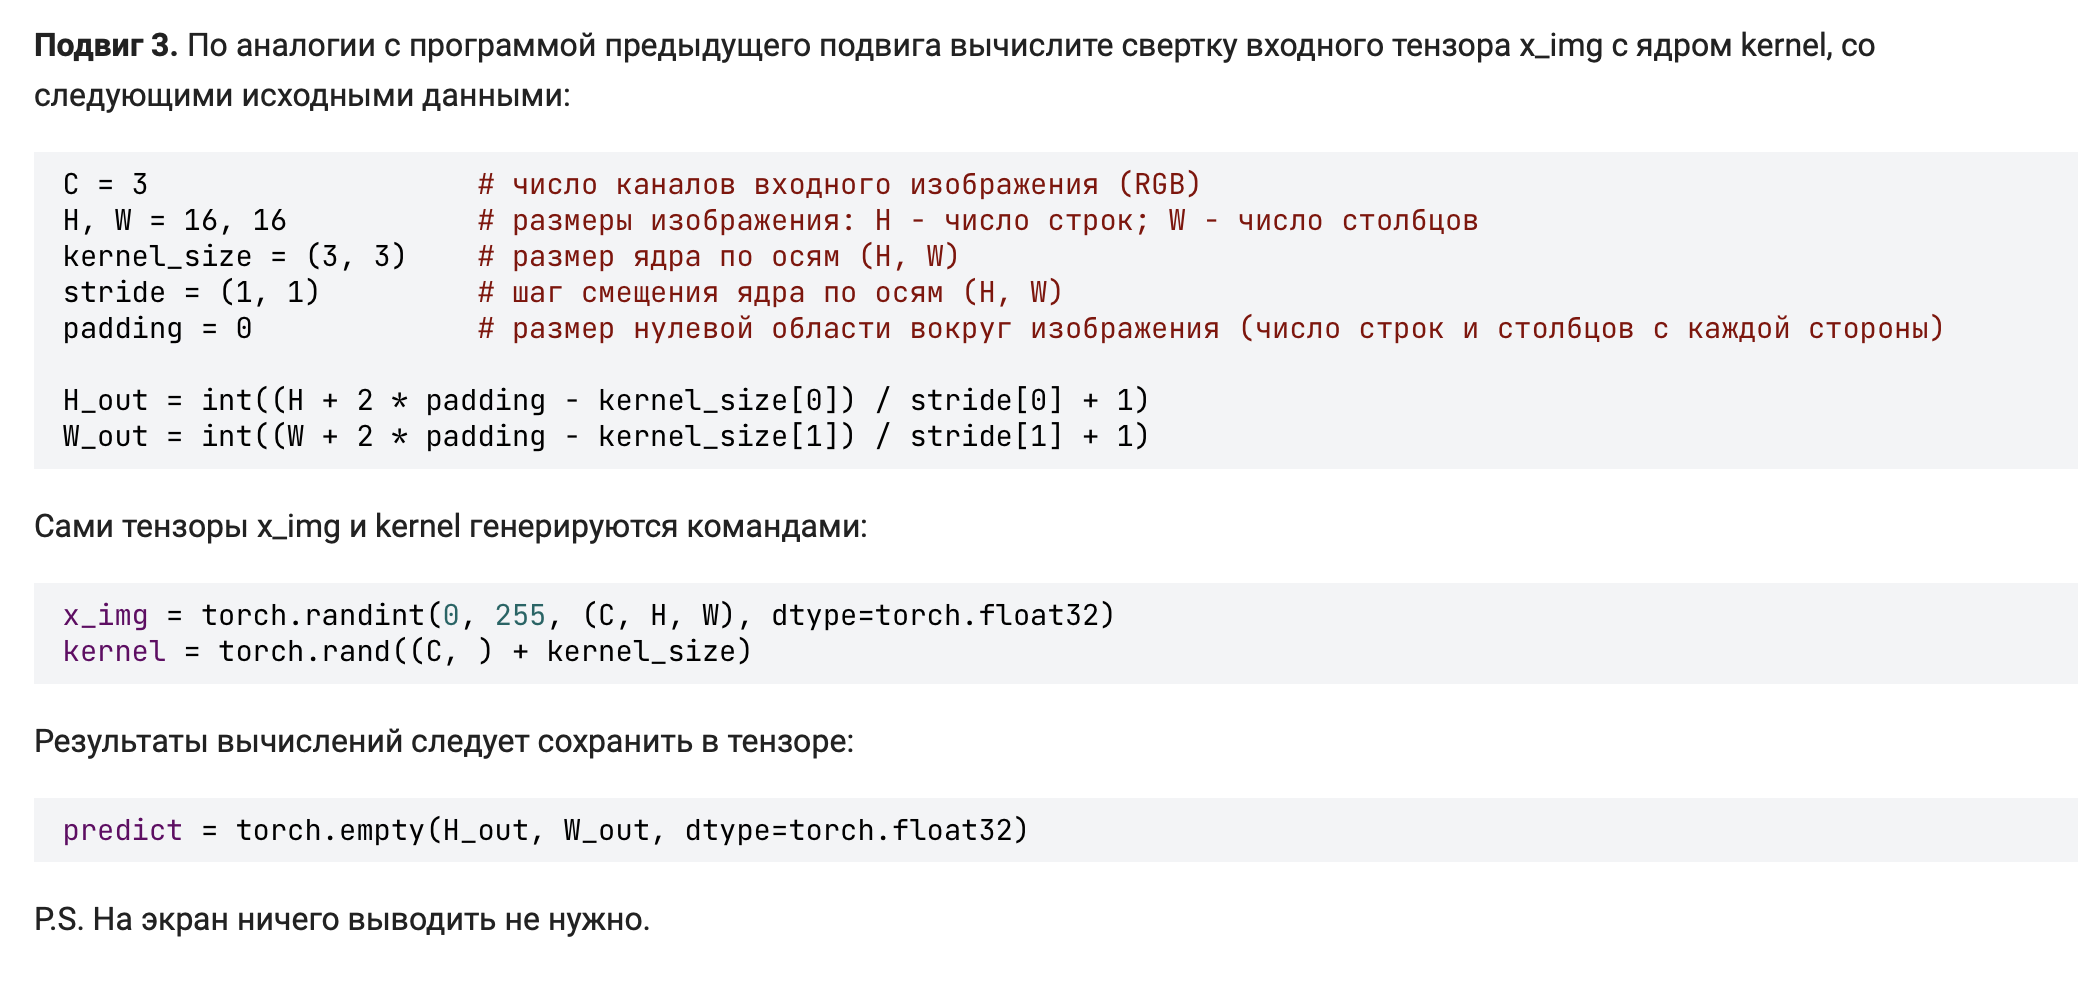

In [18]:
import torch

C = 3                   # число каналов
H, W = 16, 16           # размеры изображения: H - число строк; W - число столбцов
kernel_size = (3, 3)    # размер ядра по осям (H, W)
stride = (1, 1)         # шаг смещения ядра по осям (H, W)
padding = 0             # размер нулевой области вокруг изображения (число строк и столбцов с каждой стороны)

H_out = int((H + 2 * padding - kernel_size[0]) / stride[0] + 1)
W_out = int((W + 2 * padding - kernel_size[1]) / stride[1] + 1)

x_img = torch.randint(0, 255, (C, H, W), dtype=torch.float32) # тензоры x_img и kernel
kernel = torch.rand((C, ) + kernel_size) # в программе не менять

predict = torch.empty(H_out, W_out, dtype=torch.float32)

# здесь продолжайте программу
for i in range(H_out):
    for j in range(W_out):
        predict[i, j] = torch.sum(x_img[:, 
                                        i*stride[0]:i*stride[0]+kernel_size[0],
                                        j*stride[1]:j*stride[1]+kernel_size[1]] * kernel)

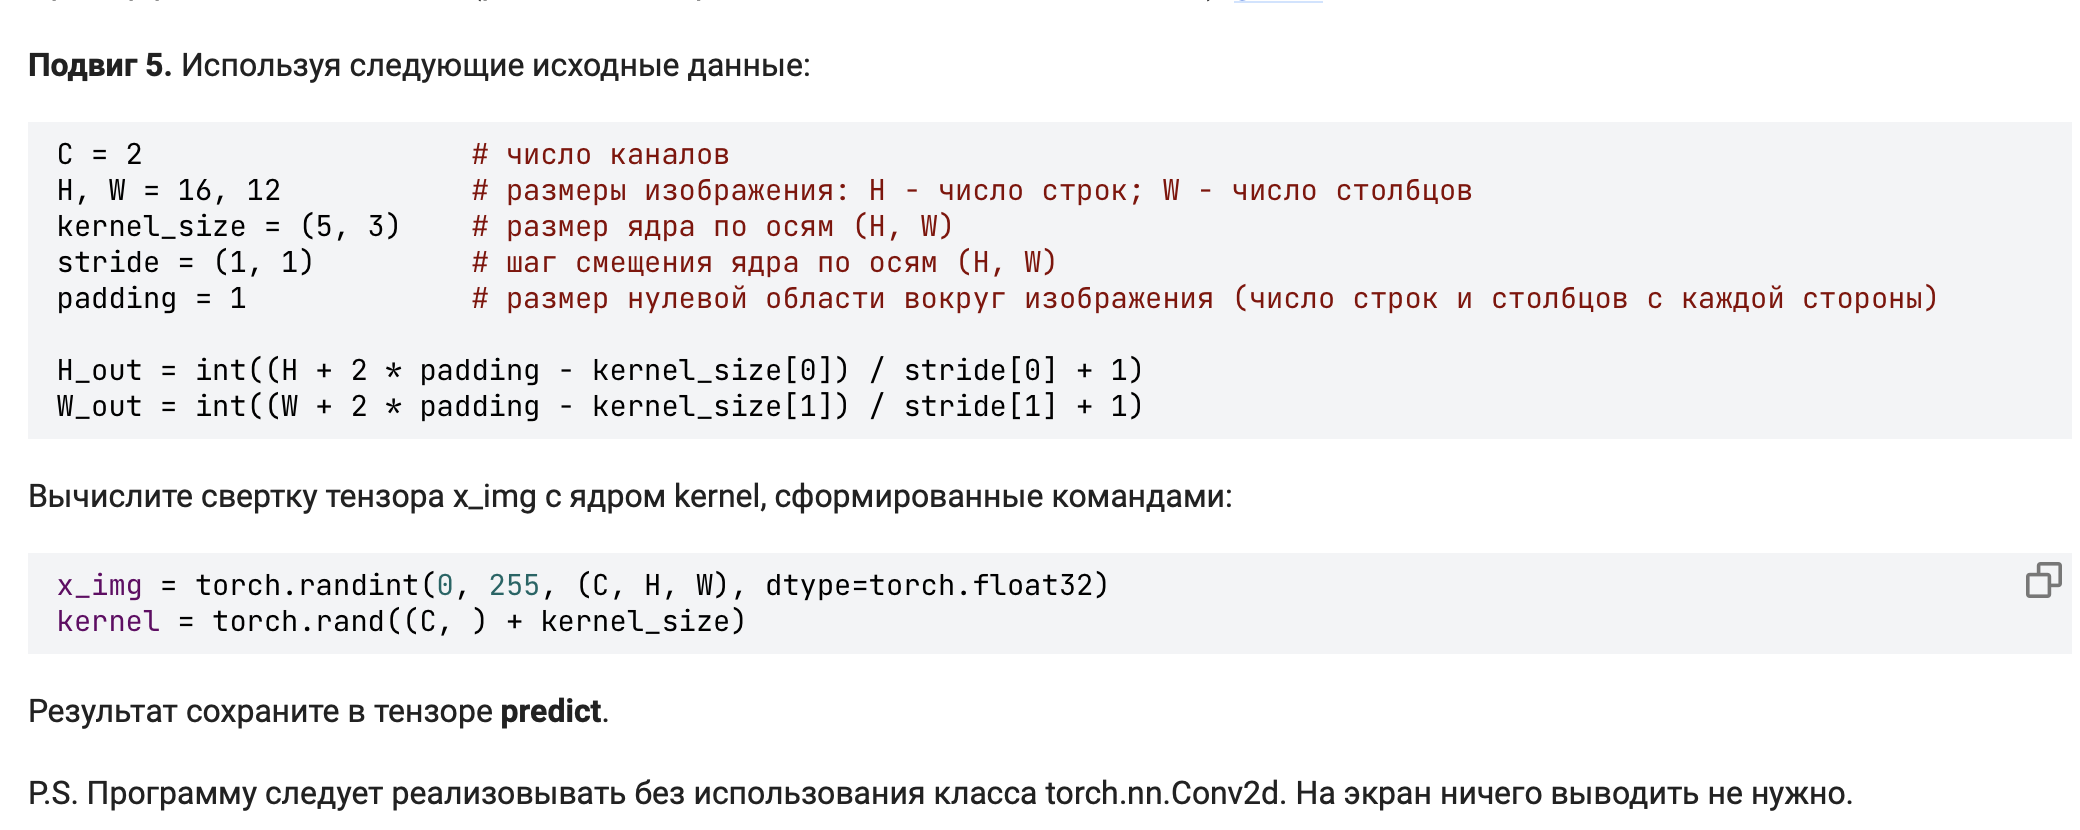

In [51]:
import torch

C = 2                   # число каналов
H, W = 16, 12           # размеры изображения: H - число строк; W - число столбцов
kernel_size = (5, 3)    # размер ядра по осям (H, W)
stride = (1, 1)         # шаг смещения ядра по осям (H, W)
padding = 1             # размер нулевой области вокруг изображения (число строк и столбцов с каждой стороны)

H_out = int((H + 2 * padding - kernel_size[0]) / stride[0] + 1)
W_out = int((W + 2 * padding - kernel_size[1]) / stride[1] + 1)

x_img = torch.randint(0, 255, (C, H, W), dtype=torch.float32) # тензоры x_img и kernel
kernel = torch.rand((C, ) + kernel_size) # в программе не менять

img = torch.zeros(C, H+2*padding, W+2*padding)
img[:, padding:img.shape[1]-padding, padding:img.shape[2]-padding] = x_img

predict = torch.empty(H_out, W_out).float()

# здесь продолжайте программу
for i in range(H_out):
    for j in range(W_out):
        predict[i, j] = torch.sum(img[:,
                              i*stride[0]:i*stride[0]+kernel_size[0],
                              j*stride[1]:j*stride[1]+kernel_size[1]] * kernel)

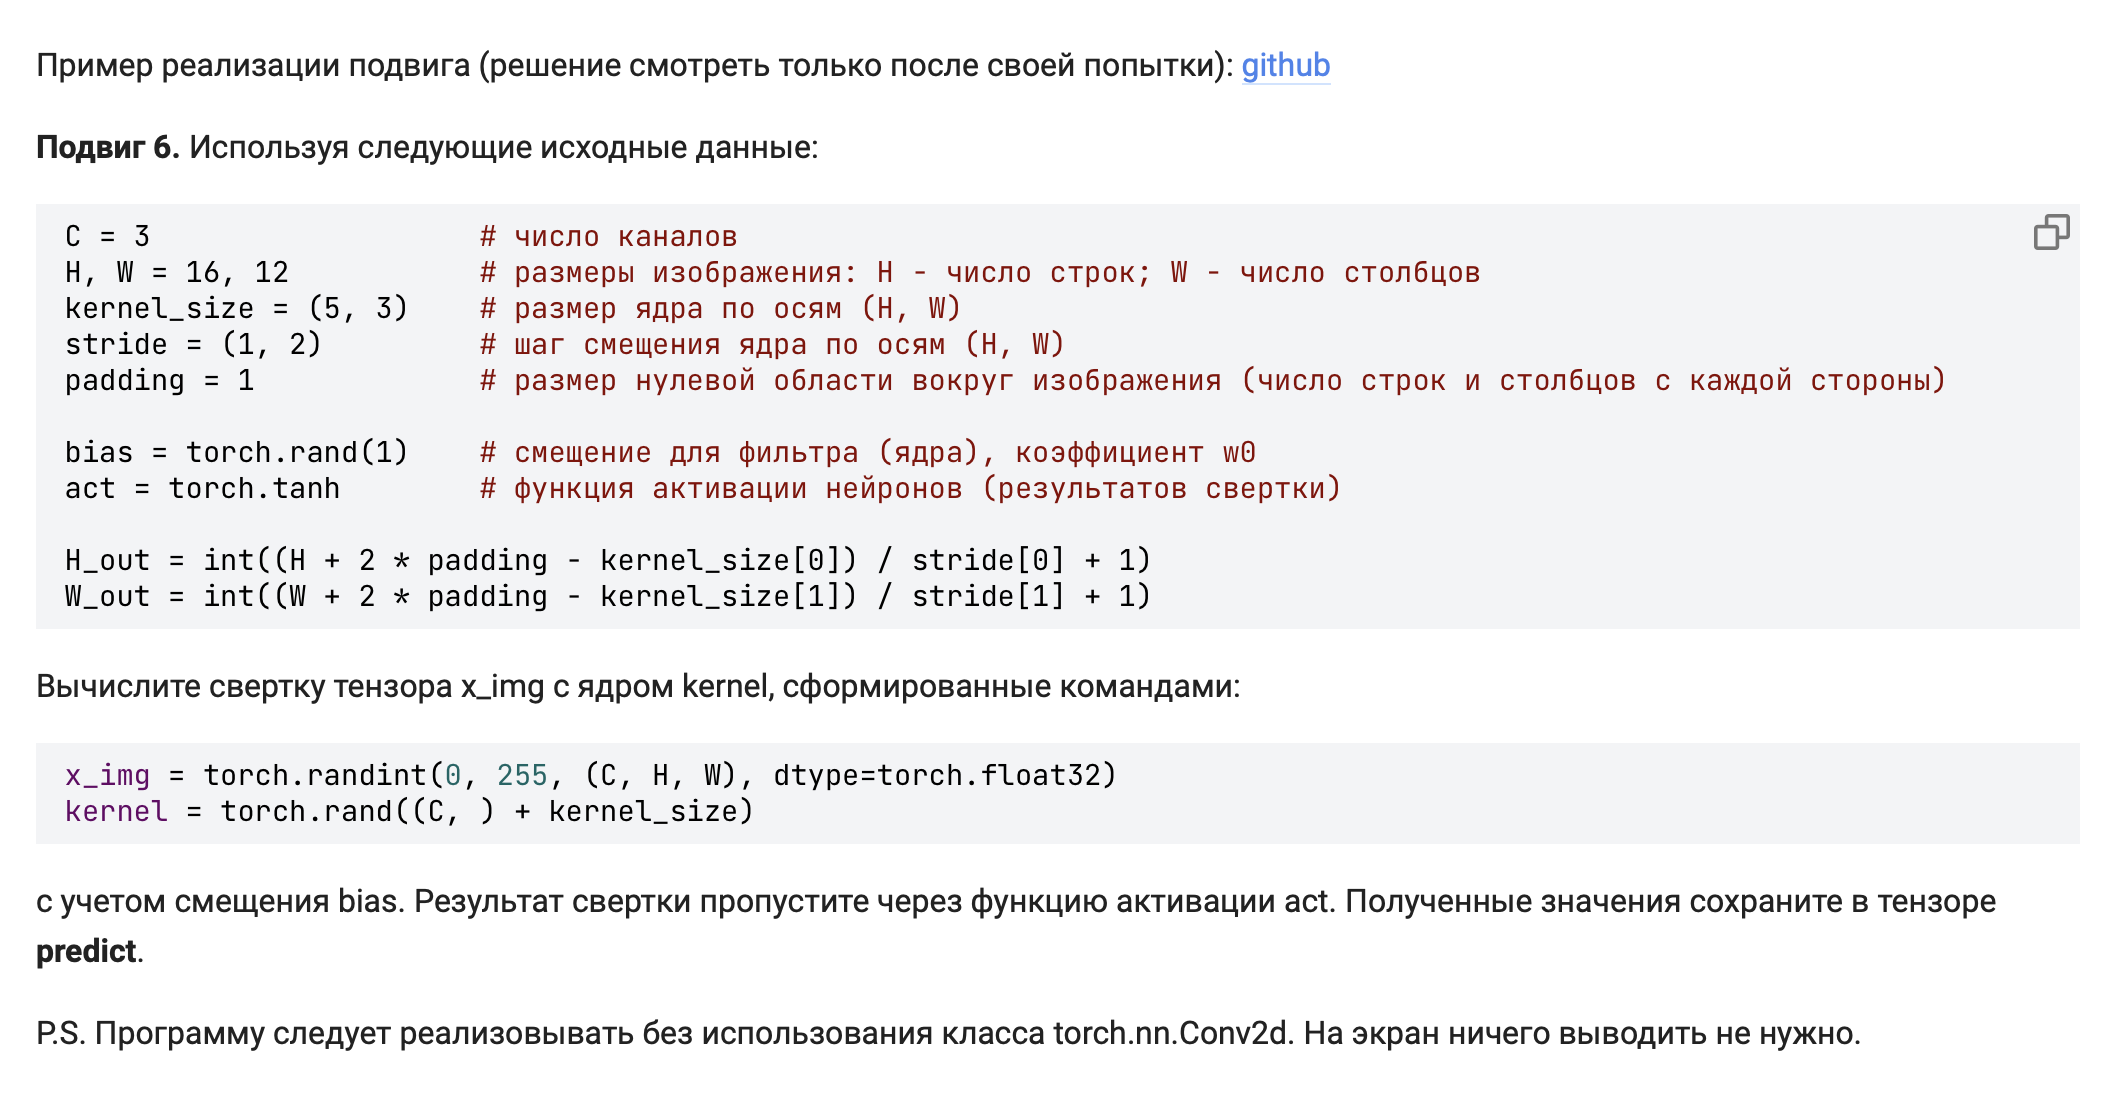

In [55]:
import torch

C = 3                   # число каналов
H, W = 16, 12           # размеры изображения: H - число строк; W - число столбцов
kernel_size = (5, 3)    # размер ядра по осям (H, W)
stride = (1, 2)         # шаг смещения ядра по осям (H, W)
padding = 1             # размер нулевой области вокруг изображения (число строк и столбцов с каждой стороны)

bias = torch.rand(1)    # смещение для фильтра (ядра), коэффициент w0
act = torch.tanh        # функция активации нейронов (результатов свертки)

H_out = int((H + 2 * padding - kernel_size[0]) / stride[0] + 1)
W_out = int((W + 2 * padding - kernel_size[1]) / stride[1] + 1)

x_img = torch.randint(0, 255, (C, H, W), dtype=torch.float32) # тензоры x_img и kernel
kernel = torch.rand((C, ) + kernel_size) # в программе не менять

# здесь продолжайте программу
img = torch.zeros(C, H+padding*2, W+padding*2).float()
img[:, padding:img.shape[1]-padding, padding:img.shape[2]-padding] = x_img

predict = torch.empty(H_out, W_out)
for i in range(H_out):
    for j in range(W_out):
        predict[i, j] = torch.sum(img[:,
                                      i*stride[0]:i*stride[0]+kernel_size[0],
                                      j*stride[1]:j*stride[1]+kernel_size[1]] * kernel)
predict = act(predict + bias)

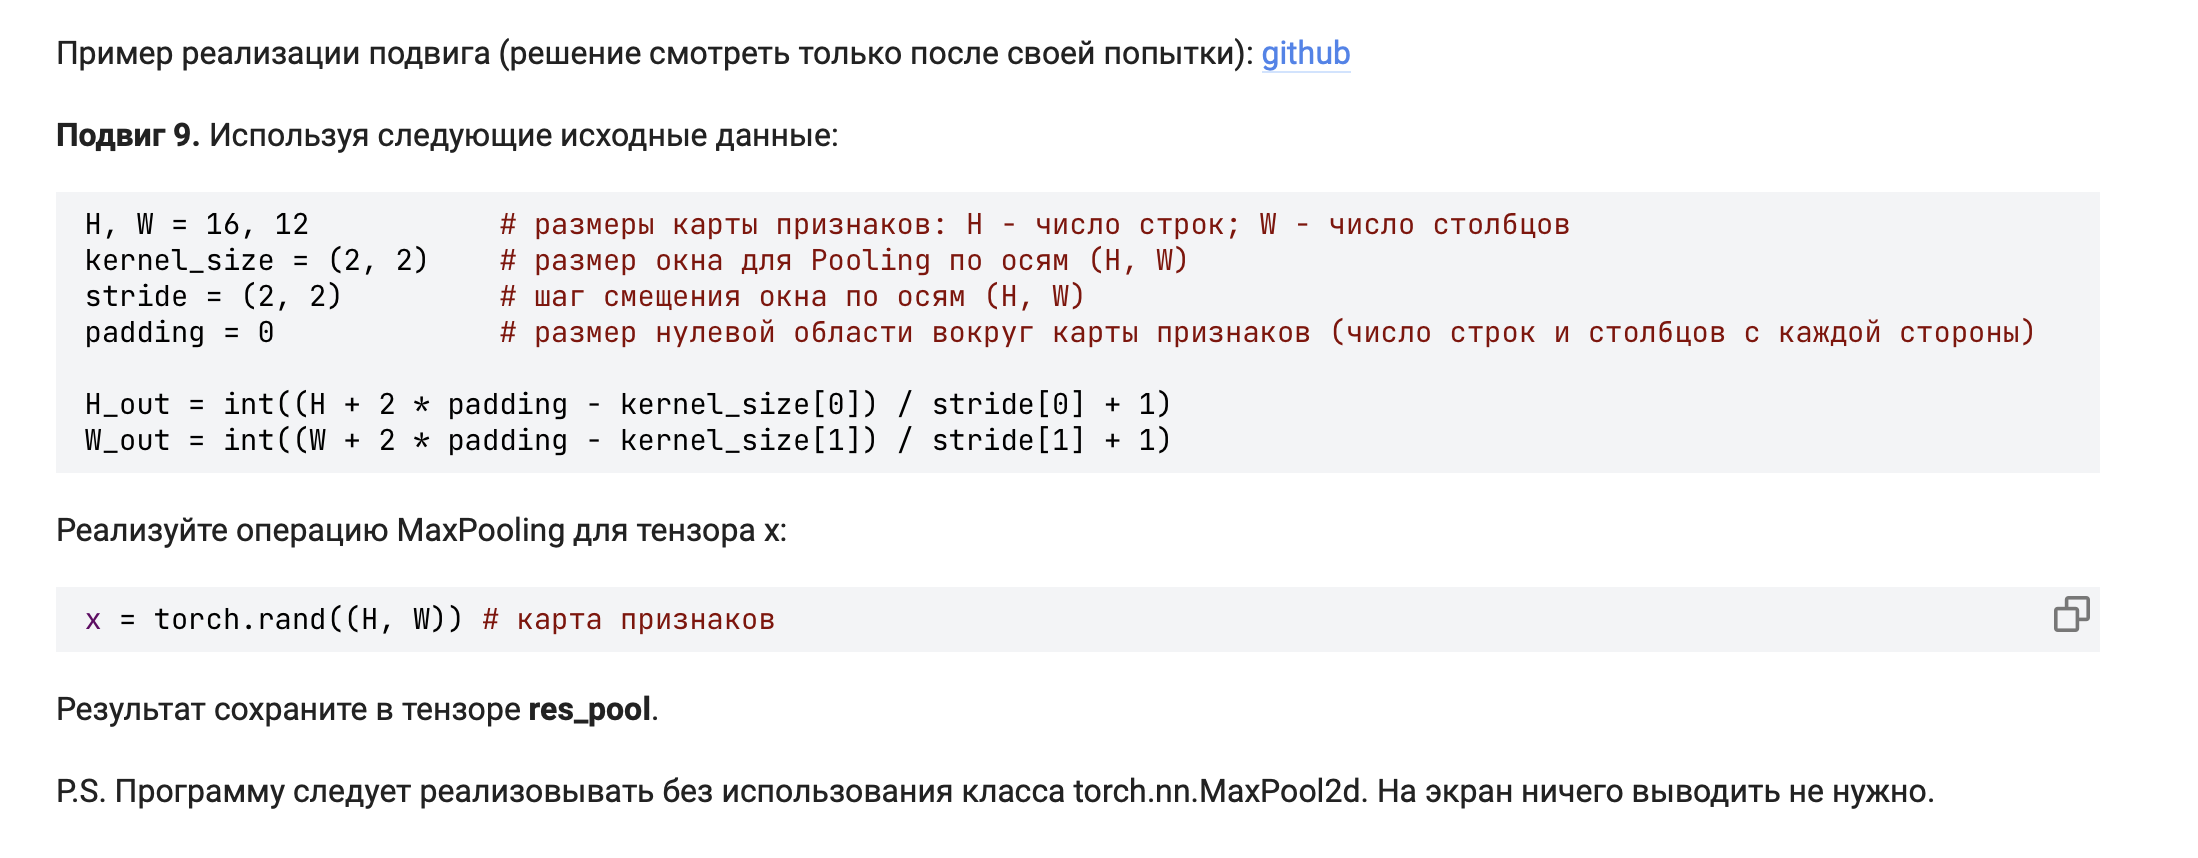

In [56]:
import torch

H, W = 16, 12           # размеры карты признаков: H - число строк; W - число столбцов
kernel_size = (2, 2)    # размер окна для Pooling по осям (H, W)
stride = (2, 2)         # шаг смещения окна по осям (H, W)
padding = 0             # размер нулевой области вокруг карты признаков (число строк и столбцов с каждой стороны)

H_out = int((H + 2 * padding - kernel_size[0]) / stride[0] + 1)
W_out = int((W + 2 * padding - kernel_size[1]) / stride[1] + 1)

x = torch.rand((H, W)) # карта признаков (в программе не менять)

res_pool = torch.empty(H_out, W_out)
# здесь продолжайте программу
for i in range(H_out):
    for j in range(W_out):
        res_pool[i, j] = torch.amax(x[i*stride[0]:i*stride[0]+kernel_size[0],
                                      j*stride[1]:j*stride[1]+kernel_size[1]])

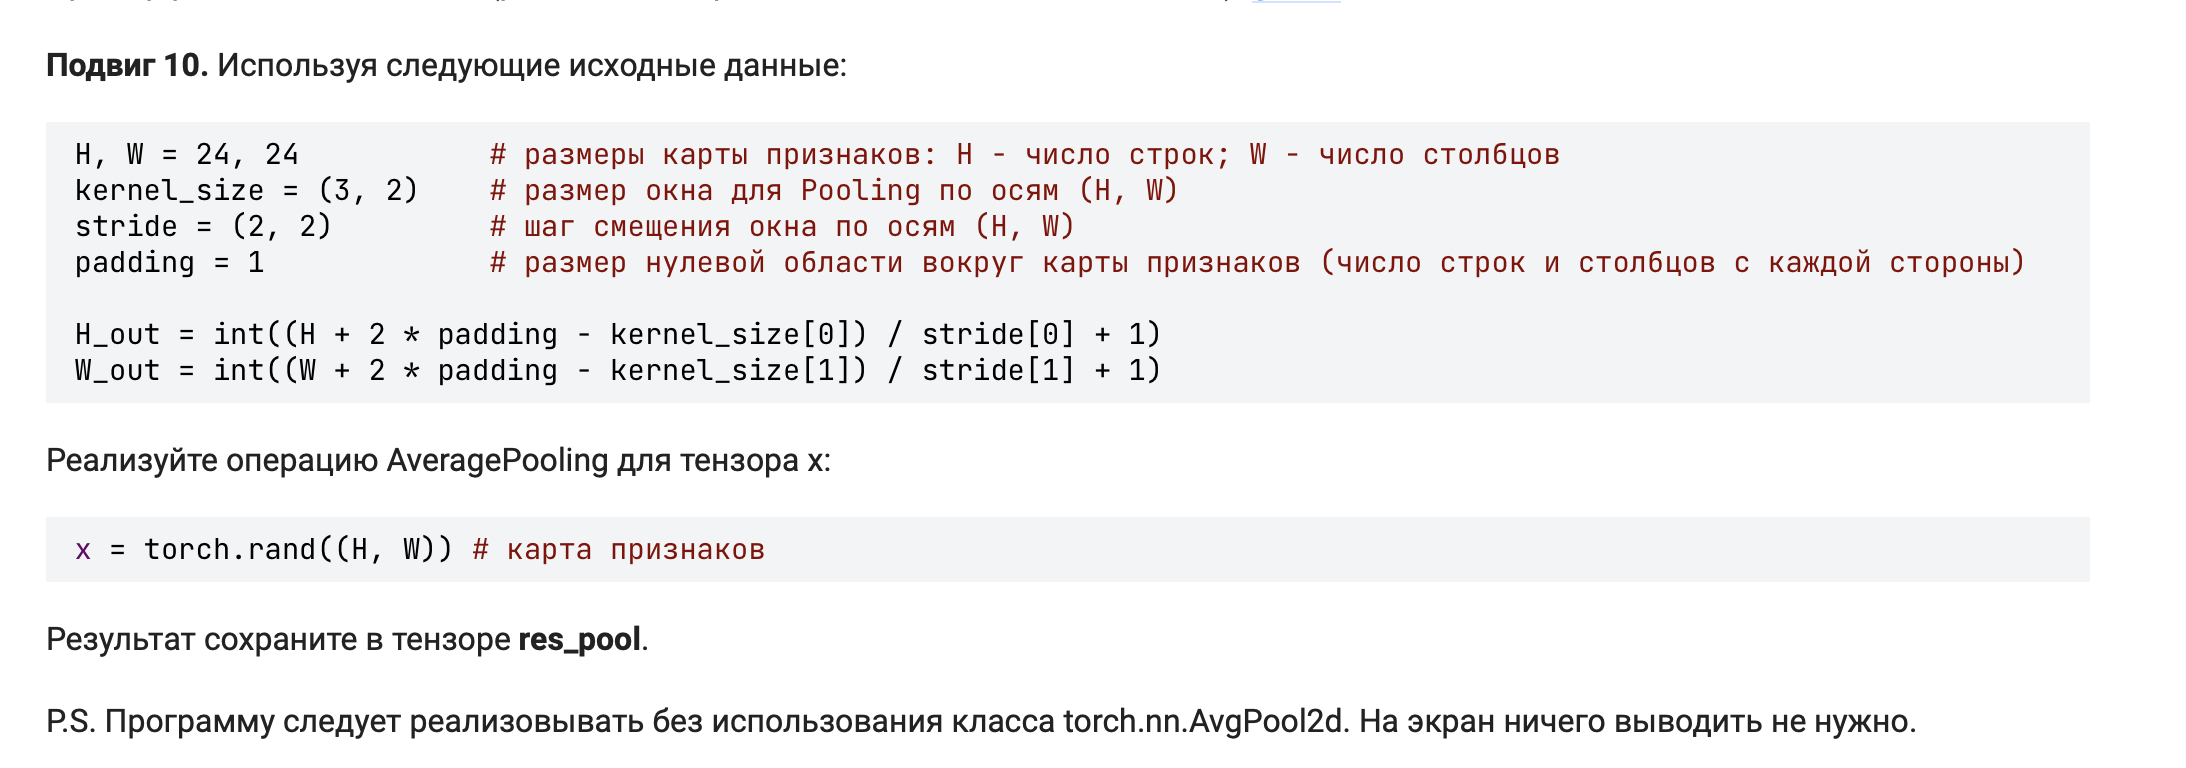

In [61]:
import torch

H, W = 24, 24           # размеры карты признаков: H - число строк; W - число столбцов
kernel_size = (3, 2)    # размер окна для Pooling по осям (H, W)
stride = (2, 2)         # шаг смещения окна по осям (H, W)
padding = 1             # размер нулевой области вокруг карты признаков (число строк и столбцов с каждой стороны)

H_out = int((H + 2 * padding - kernel_size[0]) / stride[0] + 1)
W_out = int((W + 2 * padding - kernel_size[1]) / stride[1] + 1)

x = torch.rand((H, W)) # карта признаков (в программе не менять)

# здесь продолжайте программу
img = torch.zeros(H+padding*2, W+padding*2)
img[padding:img.shape[0]-padding, padding:img.shape[1]-padding] = x

res_pool = torch.empty(H_out, W_out)
for i in range(H_out):
    for j in range(W_out):
        res_pool[i, j] = torch.mean(img[i*stride[0]:i*stride[0]+kernel_size[0],
                                        j*stride[1]:j*stride[1]+kernel_size[1]])